Cel: EDA danych ChEMBL pod względem bioaktywności.

In [ ]:
!pip -q install pyspark chembl-downloader


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Konfiguracja wizualizacji
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Pobranie ChEMBL SQLite:

In [ ]:
import chembl_downloader

sqlite_path = chembl_downloader.download_extract_sqlite()
print(sqlite_path)


/root/.data/chembl/36/chembl_36.db


Uruchamienie SparkSession i konfiguracja sterowników JDBC dla SQLite, żeby czytać tabele ChEMBL bezpośrednio do DataFrame’ów Sparka:

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("chembl-eda")
    .master("local[*]")
    .config("spark.jars.packages", "org.xerial:sqlite-jdbc:3.51.1.0")
    .getOrCreate()
)

print("Spark OK:", spark.version)
print("packages:", spark.sparkContext.getConf().get("spark.jars.packages"))


Spark OK: 4.0.2
packages: org.xerial:sqlite-jdbc:3.51.1.0


In [ ]:
jdbc_url = f"jdbc:sqlite:{sqlite_path}"
props = {"driver": "org.sqlite.JDBC"}

def load_table(name, cols=None):
    """Wczytaj tabelę z ChEMBL SQLite"""
    df = spark.read.jdbc(jdbc_url, name, properties=props)
    return df.select(*cols) if cols else df

## 1. Eksploracja danych

In [ ]:
activities = load_table("activities", [
    "activity_id", "assay_id", "molregno",
    "standard_type", "standard_relation", "standard_units", "standard_value",
    "pchembl_value", "data_validity_comment", "potential_duplicate"
])

print("\n=== PIERWSZE WIERSZE DANYCH ===")
activities.show(5, truncate=False)

print("\n=== LICZBA WIERSZY ===")
total_rows = activities.count()
print(f"Całkowita liczba pomiarów aktywności: {total_rows:,}")


=== PIERWSZE WIERSZE DANYCH ===
+-----------+--------+--------+-------------+-----------------+--------------+-------------------------+-------------+---------------------+-------------------+
|activity_id|assay_id|molregno|standard_type|standard_relation|standard_units|standard_value           |pchembl_value|data_validity_comment|potential_duplicate|
+-----------+--------+--------+-------------+-----------------+--------------+-------------------------+-------------+---------------------+-------------------+
|31863      |54505   |180094  |IC50         |>                |nM            |100000.000000000000000000|NULL         |NULL                 |0                  |
|31864      |83907   |182268  |IC50         |=                |nM            |2500.000000000000000000  |5.60         |NULL                 |0                  |
|31865      |88152   |182268  |IC50         |>                |nM            |50000.000000000000000000 |NULL         |NULL                 |0                  |
|

In [ ]:
# Wczytanie dodatkowych tabel dla pełnego kontekstu
assays = load_table("assays", ["assay_id", "tid", "assay_type", "confidence_score"])
target_dictionary = load_table("target_dictionary", ["tid", "pref_name", "target_type", "organism"])
compound_structures = load_table("compound_structures", ["molregno", "canonical_smiles", "standard_inchi_key"])

# Ujednolicenie nazw kolumn
target_dictionary = target_dictionary.withColumnRenamed("tid", "target_id")
assays = assays.withColumnRenamed("tid", "target_id")


In [ ]:
# Ponowne połączenie tabel z uwzględnieniem poprawek typów danych
df_full = (
    activities
    .join(compound_structures, "molregno", "left")
    .join(assays, "assay_id", "left")
    .join(target_dictionary, "target_id", "left")
)

print("\n=== SCHEMAT POŁĄCZONEGO DATASETU ===")
df_full.printSchema()


=== SCHEMAT POŁĄCZONEGO DATASETU ===
root
 |-- target_id: decimal(20,0) (nullable = true)
 |-- assay_id: decimal(20,0) (nullable = true)
 |-- molregno: decimal(20,0) (nullable = true)
 |-- activity_id: decimal(20,0) (nullable = true)
 |-- standard_type: string (nullable = true)
 |-- standard_relation: string (nullable = true)
 |-- standard_units: string (nullable = true)
 |-- standard_value: decimal(38,18) (nullable = true)
 |-- pchembl_value: decimal(4,2) (nullable = true)
 |-- data_validity_comment: string (nullable = true)
 |-- potential_duplicate: integer (nullable = true)
 |-- canonical_smiles: string (nullable = true)
 |-- standard_inchi_key: string (nullable = true)
 |-- assay_type: string (nullable = true)
 |-- confidence_score: integer (nullable = true)
 |-- pref_name: string (nullable = true)
 |-- target_type: string (nullable = true)
 |-- organism: string (nullable = true)



In [ ]:
df_full.groupBy("standard_type").count().orderBy(F.desc("count")).show(30, truncate=False)


+---------------------+-------+
|standard_type        |count  |
+---------------------+-------+
|Potency              |4473542|
|IC50                 |3552865|
|GI50                 |2629061|
|Inhibition           |1593108|
|Activity             |1357448|
|Percent Effect       |1328366|
|Ki                   |880730 |
|k_off                |826806 |
|kon                  |826637 |
|MIC                  |780708 |
|EC50                 |601331 |
|INHIBITION           |339133 |
|AC50                 |278273 |
|Kd                   |211134 |
|Z score              |147592 |
|Ratio IC50           |142259 |
|GI                   |131059 |
|Tissue Severity Score|128999 |
|Ratio                |123467 |
|ED50                 |106980 |
|CC50                 |104497 |
|IZ                   |96979  |
|T1/2                 |89804  |
|CL                   |77200  |
|Residual Activity    |73944  |
|FC                   |73762  |
|Solubility           |59296  |
|Stability            |59130  |
|LC50   

Wybieram typ IC50, jako że ma wiele rekordów oraz jest to precyzyjna, standardowa miara aktywności biologicznej

In [ ]:
df_full = df_full.filter(F.col("standard_type").isin('IC50'))

## 1.1 Sprawdzenie Podstawowych Statystyk (.describe(), .info())

In [ ]:
print("\n=== STATYSTYKI OPISOWE DLA ZMIENNYCH NUMERYCZNYCH ===")

df_full.select("pchembl_value", "confidence_score").describe().show(truncate=False)

print("\n=== INFORMACJE O TYPACH DANYCH I NULL VALUES ===")
df_full.select(
    F.count("*").alias("total_rows"),
    F.count("pchembl_value").alias("pchembl_non_null"),
    F.count("canonical_smiles").alias("smiles_non_null"),
    F.count("pref_name").alias("target_name_non_null")
).show()

print("\n=== ROZKŁAD JEDNOSTEK ===")
df_full.groupBy("standard_units").count().orderBy(F.desc("count")).show(10)


=== STATYSTYKI OPISOWE DLA ZMIENNYCH NUMERYCZNYCH ===
+-------+------------------+------------------+
|summary|pchembl_value     |confidence_score  |
+-------+------------------+------------------+
|count  |2434324           |3552865           |
|mean   |6.397986          |5.496989612608416 |
|stddev |1.3832260004820625|3.8334615089476585|
|min    |2.03              |0                 |
|max    |11.00             |9                 |
+-------+------------------+------------------+


=== INFORMACJE O TYPACH DANYCH I NULL VALUES ===
+----------+----------------+---------------+--------------------+
|total_rows|pchembl_non_null|smiles_non_null|target_name_non_null|
+----------+----------------+---------------+--------------------+
|   3552865|         2434324|        3540060|             3552865|
+----------+----------------+---------------+--------------------+


=== ROZKŁAD JEDNOSTEK ===
+--------------+-------+
|standard_units|  count|
+--------------+-------+
|            nM|3276327|

Miara 'nM' stanowi zdecydowaną większość danych, więc nie zadaje sobie trudu konwertowania innych danych.

In [ ]:
df_full = df_full.filter(F.col("standard_units").isin('nM'))
print(df_full.count())

3276327


## 2 Identyfikacja Braków Danych, Duplikatów i Outlierów

## 2.1 Analiza Braków Danych

               Column  Null_Count  Null_Percentage
data_validity_comment     3125863        95.407540
        pchembl_value      842003        25.699602
             organism      368765        11.255439
    standard_relation       43439         1.325844
   standard_inchi_key        7679         0.234378
     canonical_smiles        7679         0.234378
            pref_name           0         0.000000
           assay_type           0         0.000000


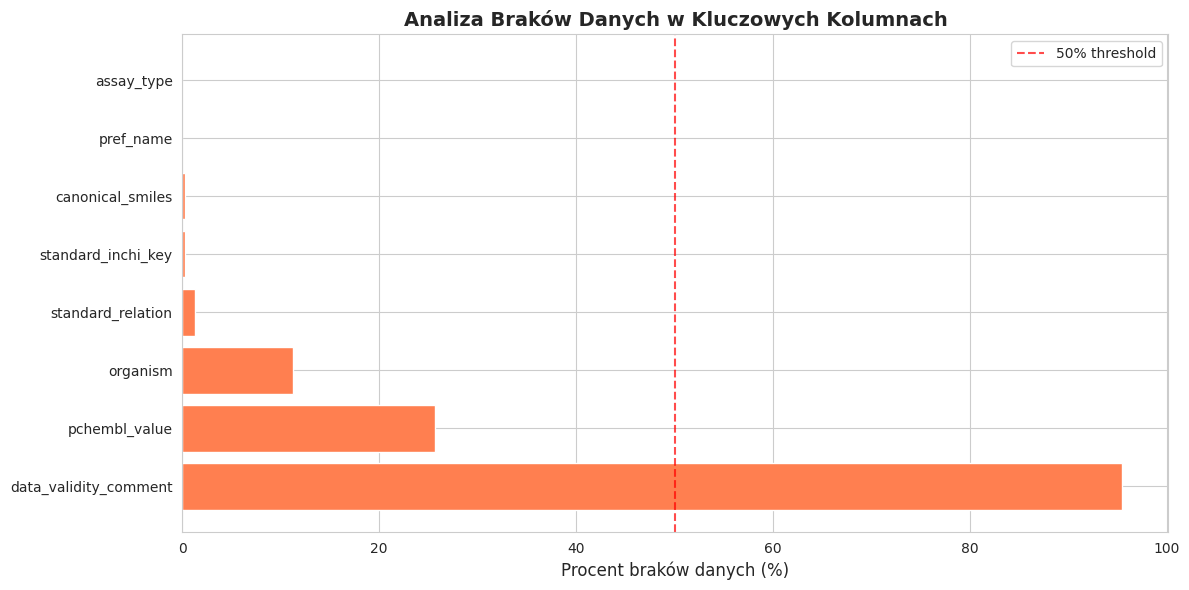

In [ ]:

# Kluczowe kolumny do analizy
key_columns = [
    "pchembl_value", "standard_relation",
    "canonical_smiles", "standard_inchi_key", "pref_name",
    "organism", "assay_type", "data_validity_comment"
]

# Poprawna logika zliczania NULL
agg_exprs = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in key_columns]
agg_exprs.append(F.count("*").alias("total_rows"))

# Wykonanie agregacji na odświeżonym df_full
stats_dict = df_full.select(agg_exprs).collect()[0].asDict()
total = stats_dict.pop("total_rows")

# Przygotowanie danych do tabeli pandas
null_data = [
    (col, count, (count / total) * 100)
    for col, count in stats_dict.items()
]

missing_data = pd.DataFrame(null_data, columns=['Column', 'Null_Count', 'Null_Percentage'])
missing_data = missing_data.sort_values('Null_Percentage', ascending=False)

print(missing_data.to_string(index=False))

# Wizualizacja
plt.figure(figsize=(12, 6))
plt.barh(missing_data['Column'], missing_data['Null_Percentage'], color='coral')
plt.xlabel('Procent braków danych (%)', fontsize=12)
plt.title('Analiza Braków Danych w Kluczowych Kolumnach', fontsize=14, weight='bold')
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("\n=== ROZKŁAD WSPÓŁCZYNNIKA ZAUFANIA (CONFIDENCE SCORE) ===")
df_full.groupBy("confidence_score").count().orderBy(F.desc("count")).show(10, truncate=False)


=== ROZKŁAD WSPÓŁCZYNNIKA ZAUFANIA (CONFIDENCE SCORE) ===
+----------------+-------+
|confidence_score|count  |
+----------------+-------+
|9               |1352436|
|1               |950819 |
|8               |532282 |
|0               |279046 |
|7               |57309  |
|6               |34248  |
|5               |33423  |
|4               |31459  |
|3               |4686   |
|2               |619    |
+----------------+-------+



Odfiltrowanie wyników niepewnych

In [ ]:
df_full = df_full.filter(F.col("confidence_score") >= 8)

## 2.2 Analiza potencjalnych duplikatów

Sprawdzamy rozkład wartości w kolumnie `potential_duplicate`, aby zidentyfikować ewentualne zduplikowane pomiary aktywności.

In [ ]:
print("\n=== ROZKŁAD POTENCJALNYCH DUPLIKATÓW ===")
df_full.groupBy("potential_duplicate").count().orderBy(F.desc("count")).show(truncate=False)


=== ROZKŁAD POTENCJALNYCH DUPLIKATÓW ===
+-------------------+-------+
|potential_duplicate|count  |
+-------------------+-------+
|0                  |1655698|
|1                  |229020 |
+-------------------+-------+



## 2.3 Liczba unikalnych związków i celów

Analizujemy liczbę unikalnych związków chemicznych (`molregno`) i celów białkowych (`target_id`) w zbiorze danych.

In [ ]:
print("\n=== LICZBA UNIKALNYCH ZWIĄZKÓW I CELÓW ===")
unique_compounds = df_full.select("molregno").distinct().count()
unique_targets = df_full.select("target_id").distinct().count()

print(f"Liczba unikalnych związków: {unique_compounds:,}")
print(f"Liczba unikalnych celów: {unique_targets:,}")


=== LICZBA UNIKALNYCH ZWIĄZKÓW I CELÓW ===
Liczba unikalnych związków: 877,019
Liczba unikalnych celów: 6,234


## 2.4 Analiza rozkładu zmiennych kategorialnych

Sprawdzamy rozkład wartości w kluczowych kolumnach kategorialnych (`organism`, `target_type`, `assay_type`), aby zidentyfikować najczęściej występujące kategorie i ocenić ich różnorodność.

In [ ]:
print("\n=== ROZKŁAD ORGANIZMÓW ===")
df_full.groupBy("organism").count().orderBy(F.desc("count")).show(10, truncate=False)


=== ROZKŁAD ORGANIZMÓW ===
+------------------------------+-------+
|organism                      |count  |
+------------------------------+-------+
|Homo sapiens                  |1603506|
|Rattus norvegicus             |72692  |
|Mus musculus                  |36368  |
|Human immunodeficiency virus 1|23015  |
|Bos taurus                    |10107  |
|Electrophorus electricus      |7327   |
|Sus scrofa                    |6731   |
|Equus caballus                |6535   |
|dengue virus type 2           |6426   |
|Plasmodium falciparum         |5573   |
+------------------------------+-------+
only showing top 10 rows


In [ ]:
print("\n=== ROZKŁAD TYPÓW CELÓW ===")
df_full.groupBy("target_type").count().orderBy(F.desc("count")).show(10, truncate=False)


=== ROZKŁAD TYPÓW CELÓW ===
+--------------+-------+
|target_type   |count  |
+--------------+-------+
|SINGLE PROTEIN|1884718|
+--------------+-------+



In [ ]:
print("\n=== ROZKŁAD TYPÓW POMIARÓW ===")
df_full.groupBy("assay_type").count().orderBy(F.desc("count")).show(10, truncate=False)


=== ROZKŁAD TYPÓW POMIARÓW ===
+----------+-------+
|assay_type|count  |
+----------+-------+
|B         |1674274|
|F         |160780 |
|A         |46872  |
|T         |2669   |
|U         |123    |
+----------+-------+



In [ ]:
df_full = df_full.filter(F.col("assay_type") == "B")
df_full.count()

1674274

In [ ]:
df_full.groupBy("data_validity_comment").count().orderBy(F.desc("count")).show(30, truncate=False)

+-----------------------------+-------+
|data_validity_comment        |count  |
+-----------------------------+-------+
|NULL                         |1626068|
|Outside typical range        |45192  |
|Potential transcription error|2979   |
|Manually validated           |35     |
+-----------------------------+-------+



Odfiltrowuje potencjalnie złe dane

In [ ]:
df_full = df_full.filter(F.col('data_validity_comment').isNull() | (F.col('data_validity_comment') == 'Manually validated'))
df_full.count()

1626103

In [ ]:
df_full.groupBy("standard_relation").count().orderBy(F.desc("count")).show(30, truncate=False)

+-----------------+-------+
|standard_relation|count  |
+-----------------+-------+
|=                |1293071|
|>                |191054 |
|<                |126698 |
|<=               |7441   |
|NULL             |4887   |
|>=               |2695   |
|~                |167    |
|>>               |90     |
+-----------------+-------+



## 2.5 Obsługa brakujących wartości w `pchembl_value` i `organism`

Usuwamy wiersze, w których brakuje kluczowych wartości `pchembl_value` i `organism`, aby zapewnić spójność i kompletność danych do dalszej analizy.

In [ ]:
print(f"Liczba wierszy przed usunięciem brakujących wartości: {df_full.count():,}")

df_full = df_full.na.drop(subset=["pchembl_value", "organism"])

print(f"Liczba wierszy po usunięciu brakujących wartości: {df_full.count():,}")

Liczba wierszy przed usunięciem brakujących wartości: 1,626,103
Liczba wierszy po usunięciu brakujących wartości: 1,292,972


## 2.6 Analiza rozkładu `pchembl_value`

Wizualizacja rozkładu wartości pChEMBL w celu zrozumienia ich natury, wykrycia skośności i potencjalnych wartości odstających.

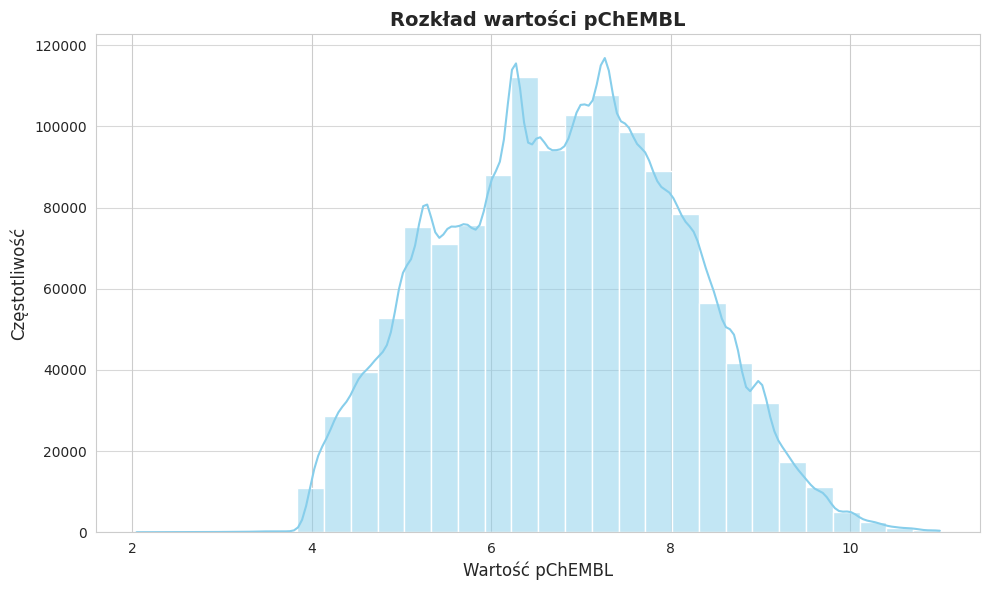

In [ ]:
# Konwertujemy Spark DataFrame na Pandas DataFrame dla wizualizacji
pchembl_values_pd = df_full.select("pchembl_value").toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(pchembl_values_pd['pchembl_value'], bins=30, kde=True, color='skyblue')
plt.title('Rozkład wartości pChEMBL', fontsize=14, weight='bold')
plt.xlabel('Wartość pChEMBL', fontsize=12)
plt.ylabel('Częstotliwość', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Odfiltrowuje dane z nieprecyzyjnym pomiarem (przyjmuję tylko ze znakiem relacji '=')

In [ ]:
df_full = df_full.filter(F.col('standard_relation').isin('='))
df_full.count()

1292972

In [ ]:
print("=== ANALIZA WARTOŚCI ODSTAJĄCYCH (OUTLIERS) ===")
# Sprawdzenie zakresów pChEMBL
df_full.select("pchembl_value").summary("min", "1%", "25%", "50%", "75%", "99%", "max").show()

# Filtracja prawdopodobnych błędów (pChEMBL zwykle mieści się w zakresie 2-14)
df_cleaned = df_full.filter((F.col("pchembl_value") >= 2) & (F.col("pchembl_value") <= 14))

=== ANALIZA WARTOŚCI ODSTAJĄCYCH (OUTLIERS) ===
+-------+-------------+
|summary|pchembl_value|
+-------+-------------+
|    min|         2.05|
|     1%|         4.16|
|    25%|          5.8|
|    50%|         6.82|
|    75%|         7.75|
|    99%|          9.7|
|    max|        11.00|
+-------+-------------+



=== TOP 15 NAJCZĘSTSZYCH CELÓW (TARGETS) ===


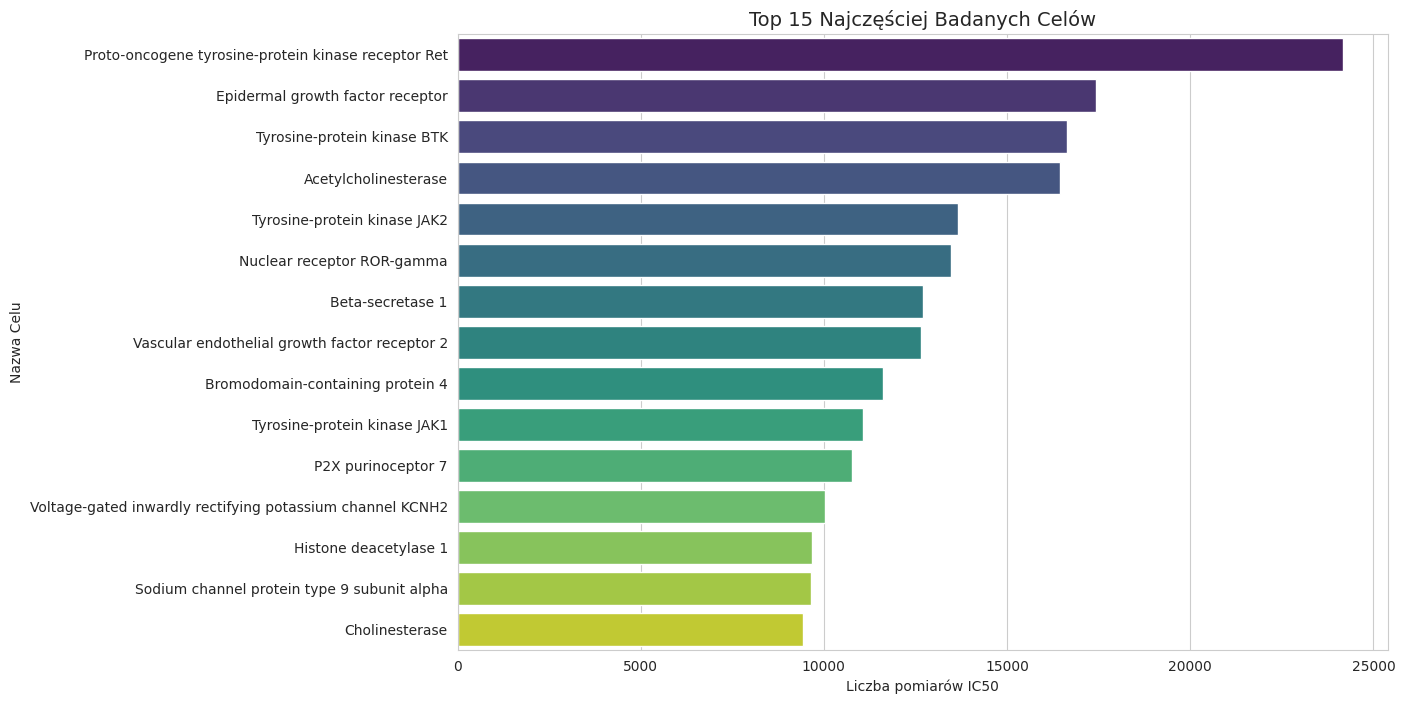

In [ ]:
print("=== TOP 15 NAJCZĘSTSZYCH CELÓW (TARGETS) ===")
top_targets = df_full.groupBy("pref_name").count().orderBy(F.desc("count")).limit(15).toPandas()

plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='pref_name', data=top_targets, palette='viridis')
plt.title('Top 15 Najczęściej Badanych Celów', fontsize=14)
plt.xlabel('Liczba pomiarów IC50')
plt.ylabel('Nazwa Celu')
plt.show()

In [ ]:
print("=== ANALIZA UNIKALNOŚCI STRUKTUR (SMILES) ===")
smiles_count = df_full.select("canonical_smiles").distinct().count()
molregno_count = df_full.select("molregno").distinct().count()

print(f"Unikalne molregno: {molregno_count}")
print(f"Unikalne SMILES: {smiles_count}")
print(f"Różnica (potencjalne duplikaty struktur): {molregno_count - smiles_count}")

=== ANALIZA UNIKALNOŚCI STRUKTUR (SMILES) ===
Unikalne molregno: 675147
Unikalne SMILES: 674283
Różnica (potencjalne duplikaty struktur): 864


In [ ]:
print("=== UŚREDNIANIE WYNIKÓW DLA PAR ZWIĄZEK-CEL ===")

# Grupowanie po molregno i target_id (używając pref_name dla czytelności)
df_averaged = df_cleaned.groupBy("molregno", "target_id", "pref_name", "canonical_smiles") \
    .agg(F.mean("pchembl_value").alias("mean_pchembl"),
         F.count("activity_id").alias("measurement_count"))

print(f"Liczba rekordów przed uśrednieniem: {df_cleaned.count():,}")
print(f"Liczba unikalnych par związek-cel: {df_averaged.count():,}")

# Pokazanie rekordów, które miały najwięcej pomiarów
print("\n=== PARY Z NAJWIĘKSZĄ LICZBĄ POMIARÓW ===")
df_averaged.orderBy(F.desc("measurement_count")).show(10, truncate=False)

=== UŚREDNIANIE WYNIKÓW DLA PAR ZWIĄZEK-CEL ===
Liczba rekordów przed uśrednieniem: 1,292,972
Liczba unikalnych par związek-cel: 959,729

=== PARY Z NAJWIĘKSZĄ LICZBĄ POMIARÓW ===
+--------+---------+---------------------------------------------------------+----------------------------------------------------------------+------------+-----------------+
|molregno|target_id|pref_name                                                |canonical_smiles                                                |mean_pchembl|measurement_count|
+--------+---------+---------------------------------------------------------+----------------------------------------------------------------+------------+-----------------+
|11305   |12697    |Histone deacetylase 1                                    |O=C(CCCCCCC(=O)Nc1ccccc1)NO                                     |7.301777    |377              |
|11305   |11307    |Histone deacetylase 6                                    |O=C(CCCCCCC(=O)Nc1ccccc1)NO               

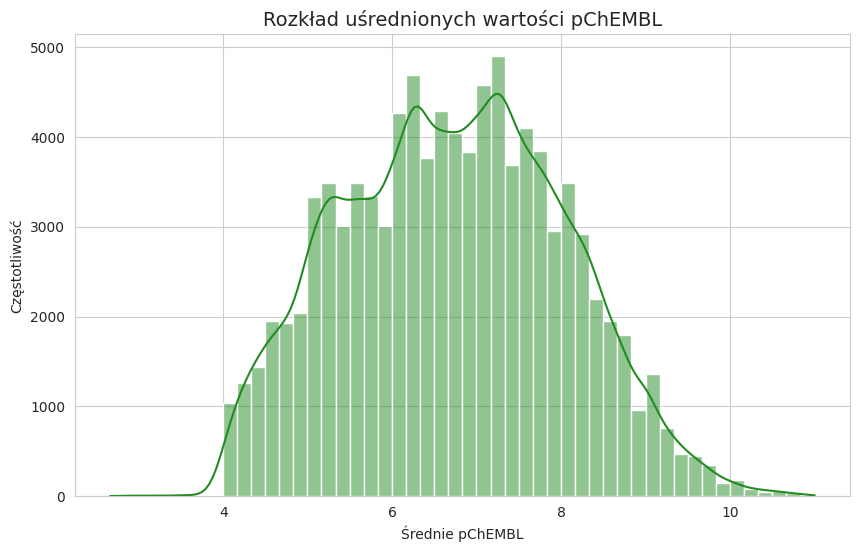

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wizualizacja rozkładu uśrednionych wartości
pd_avg = df_averaged.select("mean_pchembl").sample(0.1).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(pd_avg['mean_pchembl'], bins=50, kde=True, color='forestgreen')
plt.title('Rozkład uśrednionych wartości pChEMBL', fontsize=14)
plt.xlabel('Średnie pChEMBL')
plt.ylabel('Częstotliwość')
plt.show()

# Inżynieria cech

In [ ]:
df = df_averaged.toPandas()

print(f"Wierszy wczytanych: {len(df):,}")
print(f"Kolumny: {list(df.columns)}")
print(df.head(3))

Wierszy wczytanych: 959,729
Kolumny: ['molregno', 'target_id', 'pref_name', 'canonical_smiles', 'mean_pchembl', 'measurement_count']
  molregno target_id                                  pref_name  \
0   109138        55  Polyunsaturated fatty acid 5-lipoxygenase   
1   136178       108            5-hydroxytryptamine receptor 2C   
2   141397        55  Polyunsaturated fatty acid 5-lipoxygenase   

                                    canonical_smiles mean_pchembl  \
0  CCCCCCOc1c(-c2ccc(O)c(O)c2)oc2cc(OC)c(OC)c(OC)...     6.900000   
1         CN(C)CC1CC2c3cccc(C(F)(F)F)c3Cc3ccccc3N2O1     6.360000   
2      COC1(c2cccc(OCc3ccc4c(ccc(=O)n4C)c3)c2)CCOCC1     7.520000   

   measurement_count  
0                  1  
1                  1  
2                  1  


# 1. Które cechy wymagają transformacji?

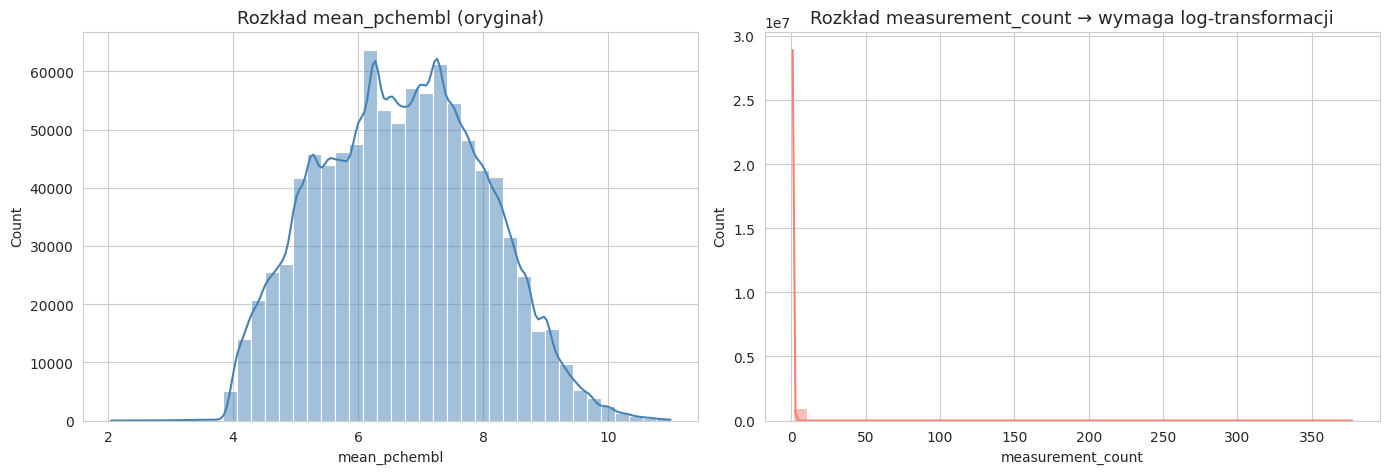


Statystyki measurement_count przed/po log-transformacji:
       measurement_count  log_measurement_count
count         959729.000             959729.000
mean               1.347                  0.804
std                1.570                  0.261
min                1.000                  0.693
25%                1.000                  0.693
50%                1.000                  0.693
75%                1.000                  0.693
max              377.000                  5.935

Wnioski:
  • mean_pchembl: już na skali -log10(IC50) → bez dalszej transformacji.
  • measurement_count: silna skośność prawostronna → zastosowano log1p.
  • Cechy kategorialne (pref_name, organism): wymagają kodowania (Label Encoding).



In [ ]:
# 1a. mean_pchembl — już w skali -log10, sprawdzamy rozkład
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title("Rozkład mean_pchembl (oryginał)", fontsize=13)
sns.histplot(df['mean_pchembl'].dropna(), bins=40, kde=True,
             color='steelblue', ax=axes[0])
axes[0].set_xlabel("mean_pchembl")

# 1b. measurement_count — wyraźna skośność prawostronea → log-transform
axes[1].set_title("Rozkład measurement_count → wymaga log-transformacji", fontsize=13)
sns.histplot(df['measurement_count'], bins=40, kde=True,
             color='salmon', ax=axes[1])
axes[1].set_xlabel("measurement_count")

plt.tight_layout()
plt.savefig("/tmp/01_distributions_before.png", dpi=120)
plt.show()

# Zastosowanie log1p dla measurement_count
df['log_measurement_count'] = np.log1p(df['measurement_count'])

print("\nStatystyki measurement_count przed/po log-transformacji:")
print(df[['measurement_count', 'log_measurement_count']].describe().round(3))

print("""
Wnioski:
  • mean_pchembl: już na skali -log10(IC50) → bez dalszej transformacji.
  • measurement_count: silna skośność prawostronna → zastosowano log1p.
  • Cechy kategorialne (pref_name, organism): wymagają kodowania (Label Encoding).
""")

2. TWORZENIE NOWYCH CECH

In [ ]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 30.5 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
print("\n--- 2a. Deskryptory molekularne (RDKit) ---")

def compute_rdkit_descriptors(smiles: str) -> dict:
    """
    Oblicza podstawowe deskryptory molekularne dla podanego SMILES.
    Zwraca słownik z wartościami lub NaN przy błędzie parsowania.
    """
    empty = {
        'MW': np.nan, 'LogP': np.nan, 'TPSA': np.nan,
        'HBD': np.nan, 'HBA': np.nan
    }
    if not smiles or not isinstance(smiles, str):
        return empty
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return empty
    return {
        'MW':   Descriptors.MolWt(mol),                         # masa cząsteczkowa
        'LogP': Descriptors.MolLogP(mol),                       # lipofilowość
        'TPSA': rdMolDescriptors.CalcTPSA(mol),                 # polarna pow. dostępna
        'HBD':  rdMolDescriptors.CalcNumHBD(mol),               # donory wiązań H
        'HBA':  rdMolDescriptors.CalcNumHBA(mol),               # akceptory wiązań H
    }

desc_records = df['canonical_smiles'].apply(compute_rdkit_descriptors)
desc_df = pd.DataFrame(desc_records.tolist(), index=df.index)

df = pd.concat([df, desc_df], axis=1)

print(f"Deskryptory obliczone. Braki (NaN) na {desc_df.isna().any(axis=1).sum()} / {len(df)} wierszy.")
print(desc_df.describe().round(3))


--- 2a. Deskryptory molekularne (RDKit) ---
Deskryptory obliczone. Braki (NaN) na 1143 / 959729 wierszy.
               MW        LogP        TPSA         HBD         HBA
count  958586.000  958586.000  958586.000  958586.000  958586.000
mean      465.209       3.701     100.481       2.169       5.728
std       231.355       2.121      94.977       3.454       3.565
min        42.394    -113.011       0.000       0.000       0.000
25%       372.378       2.745      67.930       1.000       4.000
50%       439.520       3.781      89.060       2.000       5.000
75%       510.398       4.835     112.100       3.000       7.000
max      7755.060      36.838    3107.580     103.000     145.000

--- 2b. Agregacje per związek (multi-target coverage) ---
        n_targets  std_activity
count  959729.000    959729.000
mean        2.904         0.372
std        14.595         0.552
min         1.000         0.000
25%         1.000         0.000
50%         1.000         0.000
75%         2.000

In [ ]:
print("\n--- 2b. Agregacje per związek ---")

compound_agg = (
    df.groupby('molregno')
    .agg(
        n_targets      = ('target_id', 'nunique'),
        mean_activity  = ('mean_pchembl', 'mean'),
        std_activity   = ('mean_pchembl', 'std'),
        max_activity   = ('mean_pchembl', 'max'),
    )
    .reset_index()
)

df = df.merge(compound_agg, on='molregno', how='left')
df['std_activity'] = df['std_activity'].fillna(0)   # 1 pomiar -> std = 0

print(df[['n_targets', 'mean_activity', 'std_activity', 'max_activity']].describe().round(3))


--- 2b. Agregacje per związek ---
        n_targets  mean_activity  std_activity  max_activity
count  959729.000     959729.000    959729.000    959729.000
mean        2.904          6.712         0.372         7.067
std        14.595          1.199         0.552         1.297
min         1.000          2.160         0.000         2.160
25%         1.000          5.850         0.000         6.160
50%         1.000          6.708         0.000         7.160
75%         2.000          7.540         0.665         8.000
max       393.000         11.000         4.695        11.000


In [ ]:
df['mean_pchembl'] = pd.to_numeric(df['mean_pchembl'], errors='coerce')

if 'target_mean_activity' in df.columns:
    df = df.drop(columns=['target_mean_activity'])

target_mean = (
    df.groupby('target_id')['mean_pchembl']
    .mean()
    .rename('target_mean_activity')
    .reset_index()
)

df = df.merge(target_mean, on='target_id', how='left')

df['target_mean_activity'] = pd.to_numeric(df['target_mean_activity'], errors='coerce')

print(f"Liczba unikalnych celów: {df['target_id'].nunique()}")
print("\nStatystyki target_mean_activity:")
print(df['target_mean_activity'].describe().round(3))
print("\nTop 5 celów z najwyższą średnią aktywnością:")
print(
    df[['pref_name', 'target_mean_activity']]
    .drop_duplicates('pref_name')
    .nlargest(5, 'target_mean_activity')
    .to_string(index=False)
)

Liczba unikalnych celów: 5376

Statystyki target_mean_activity:
count    959729.000
mean          6.712
std           0.711
min           3.549
25%           6.269
50%           6.768
75%           7.233
max          11.000
Name: target_mean_activity, dtype: float64

Top 5 celów z najwyższą średnią aktywnością:
                                                                        pref_name  target_mean_activity
                            cAMP-dependent protein kinase alpha-catalytic subunit             10.800000
Serine/threonine-protein phosphatase 2A 55 kDa regulatory subunit B alpha isoform             10.190000
                                                                        Cyclin-T1             10.156196
  Serine/threonine-protein phosphatase 2A 56 kDa regulatory subunit alpha isoform             10.013333
                         GMP-stimulated 3',5'-cyclic nucleotide phosphodiesterase             10.000000


# 3. Obsługa brakujących wartości

In [ ]:
feature_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA',
                'log_measurement_count', 'n_targets',
                'std_activity', 'target_mean_activity']

missing_before = df[feature_cols].isna().sum()
missing_pct    = (missing_before / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Braki': missing_before,
    'Procent (%)': missing_pct,
    'Strategia': [
        'Mediana (błąd parsowania SMILES)',  # MW
        'Mediana',                            # LogP
        'Mediana',                            # TPSA
        'Mediana',                            # HBD
        'Mediana',                            # HBA
        'Brak braków (obliczone)',            # log_measurement_count
        'Brak braków (obliczone)',            # n_targets
        'Wypełnione 0 (1 pomiar)',            # std_activity
        'Mediana (nowe cele bez historii)',   # target_mean_activity
    ]
})
print(missing_summary.to_string())

# Imputacja medianami dla deskryptorów RDKit i target_mean_activity
rdkit_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA']
imputer = SimpleImputer(strategy='median')
df[rdkit_cols] = imputer.fit_transform(df[rdkit_cols])

# target_mean_activity: nowe cele bez historii pomiarów → imputacja medianą
df['target_mean_activity'] = df['target_mean_activity'].fillna(
    df['target_mean_activity'].median()
)

missing_after = df[feature_cols].isna().sum().sum()
print(f"\nBraki po imputacji: {missing_after}")

                       Braki  Procent (%)                         Strategia
MW                         0          0.0  Mediana (błąd parsowania SMILES)
LogP                       0          0.0                           Mediana
TPSA                       0          0.0                           Mediana
HBD                        0          0.0                           Mediana
HBA                        0          0.0                           Mediana
log_measurement_count      0          0.0           Brak braków (obliczone)
n_targets                  0          0.0           Brak braków (obliczone)
std_activity               0          0.0           Wypełnione 0 (1 pomiar)
target_mean_activity       0          0.0  Mediana (nowe cele bez historii)

Braki po imputacji: 0


# 4. Ważność cech - random forest

Rozmiar zbioru do modelu: 959,729 wierszy × 9 cech

Ranking ważności cech:
target_mean_activity     0.827082
MW                       0.088739
std_activity             0.023621
TPSA                     0.015255
n_targets                0.012637
log_measurement_count    0.010152
LogP                     0.008524
HBD                      0.008269
HBA                      0.005720


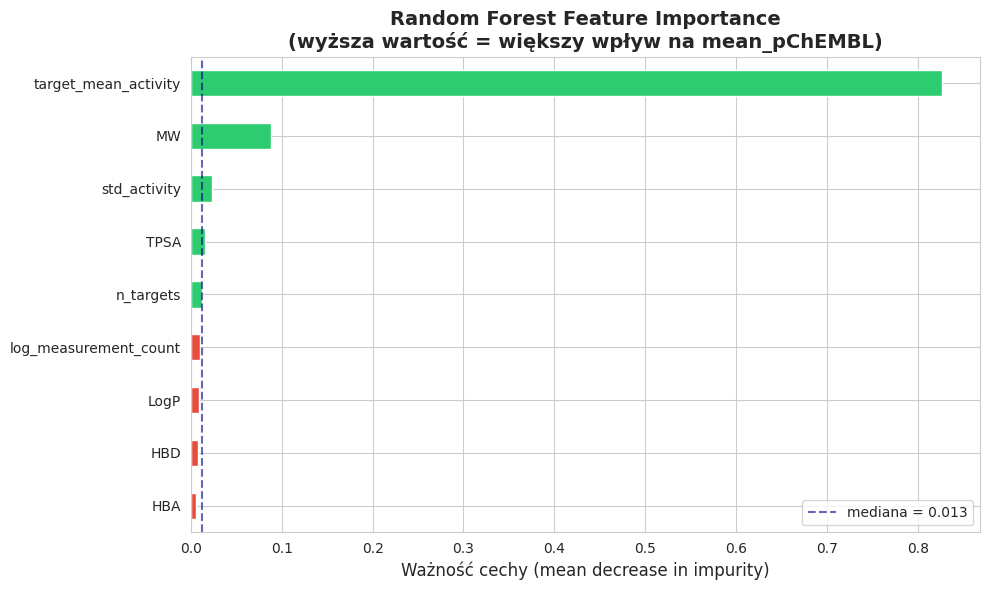

In [ ]:
# Przygotowanie zbioru
df_model = df[feature_cols + ['mean_pchembl']].dropna()
X = df_model[feature_cols].values
y = df_model['mean_pchembl'].values

print(f"Rozmiar zbioru do modelu: {X.shape[0]:,} wierszy × {X.shape[1]} cech")

# Trening Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

# Wyniki
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

print("\nRanking ważności cech:")
print(importances.sort_values(ascending=False).to_string())

# Wizualizacja
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v >= importances.median() else '#e74c3c'
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Random Forest Feature Importance\n(wyższa wartość = większy wpływ na mean_pChEMBL)',
             fontsize=14, weight='bold')
ax.set_xlabel('Ważność cechy (mean decrease in impurity)', fontsize=12)
ax.axvline(x=importances.median(), color='navy', linestyle='--',
           alpha=0.6, label=f'mediana = {importances.median():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/04_feature_importance.png", dpi=120)
plt.show()


--- Korelacja deskryptorów z mean_pchembl ---


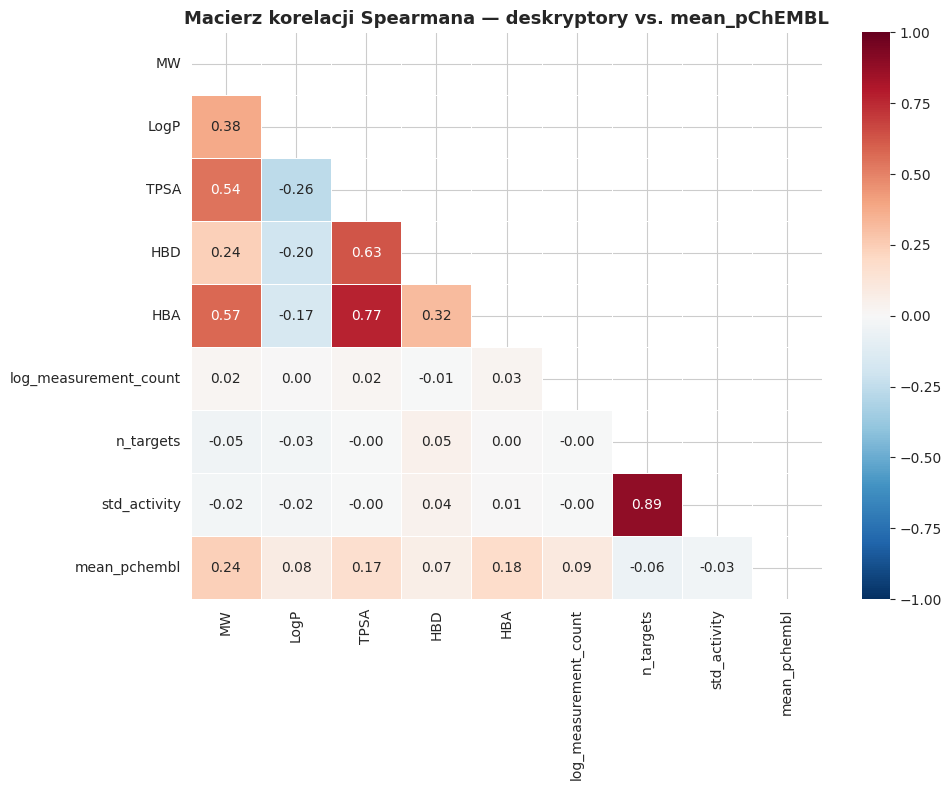

In [ ]:
print("\n--- Korelacja deskryptorów z mean_pchembl ---")

corr_cols = rdkit_cols + ['log_measurement_count', 'n_targets', 'std_activity', 'mean_pchembl']
corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Macierz korelacji Spearmana — deskryptory vs. mean_pChEMBL',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig("/tmp/04_spearman_heatmap.png", dpi=120)
plt.show()

# Inżynieria Cech — Podsumowanie
**Zbiór:** ChEMBL, IC50 [nM], confidence score ≥ 8, assay type B

---

## 1. Finalne cechy

| Cecha | Źródło | Uzasadnienie |
|---|---|---|
| `MW`, `LogP`, `TPSA`, `HBD`, `HBA` | RDKit | Podstawowe deskryptory fizykochemiczne (reguła Lipińskiego); opisują przepuszczalność błon i lipofilowość. |
| `log_measurement_count` | agregacja | Liczba pomiarów per para związek–cel (log1p); wyższa wartość = bardziej wiarygodny wynik. |
| `n_targets` | agregacja | Liczba celów testowanych dla danego związku; wskaźnik selektywności. |
| `std_activity` | agregacja | Odchylenie std. aktywności związku across celów; niska wartość = aktywność niespecyficzna. |
| `target_mean_activity` | agregacja | Średnia pChEMBL per cel; koduje "podatność" celu na inhibicję. Najsilniejszy predyktor (importance = 0.827). |

---

## 2. Kluczowe spostrzeżenia

**Cel dominuje nad cząsteczką.** `target_mean_activity` odpowiada za 82.7% ważności modelu — tożsamość celu białkowego jest silniejszym wyznacznikiem aktywności niż właściwości fizykochemiczne związku.

**Zbiór zgodny z przestrzenią leków.** Średnie wartości deskryptorów (MW ≈ 465 Da, LogP ≈ 3.7, TPSA ≈ 100 Ų) są zgodne z regułą Lipińskiego, choć zbiór zawiera też makrocząsteczki (MW do 7755 Da), które mogą zaburzać model.

**Większość par zbadana tylko raz.** Ponad 75% par związek–cel ma dokładnie jeden pomiar, przez co `std_activity` = 0 dla większości rekordów i cechy agregacyjne mają ograniczoną informatywność.
